# $$Outliers$$

- outliers are values that are unusually far from the most of the values
- 

- [Read about Statistics](https://www.geeksforgeeks.org/maths/introduction-to-statistics/)
- [Read about Outliers](https://www.geeksforgeeks.org/machine-learning/what-are-outliers-in-data/)

### Distribution of data
- how data is distributed
- 
- Variance - when there is a lot of variation in data
    - min is really small
    - max is really big
    - we say there is a lot of variance
- std deviation is the root of variance
    - variance becomes the squared of the original metric 
    - but std deviation, works in actual metric
    - this makes a good method for data distribution as well

![](https://upload.wikimedia.org/wikipedia/commons/thumb/2/22/Empirical_rule_histogram.svg/960px-Empirical_rule_histogram.svg.png)

- handling outliers
    - data beyond the third deviation, treat that as outliers

#### Inter Quartile Range
- data --> increasing order ---> break into 4 parts (Quarters)
- 
- first - 25% percentile --> First Quartile
- second - 50% percentile --> Second Quartile
- third - 75% percentile --> Third Quartile
- Fourth - 100% percentile --> Fourth Quartile

- 
-  IQR - from 25% to 75%
- 

In [63]:
import pandas as pd

df = pd.DataFrame({
    'age':         [3, 25, 26, 27, 28, 29, 25, 26, 78, 21, 24, 70, 65], 
    'temperature': [1,20,22,35,31,30,29,33,26,26,27,29,99,],
    'amount': [x for x in range(1,12)] + [45,98]
})

- you observed the mode - the most frequent
    - if you have a `sample space`, 
        - the mode will represent the `population`

In [64]:
df.head()

# Defining the quartile of the data
Q1 = df.amount.quantile(0.25)
Q2 = df.amount.quantile(0.50)
Q3 = df.amount.quantile(0.75)
Q4 = df.amount.quantile(0.100)

IQR = Q3 - Q1
IQR

np.float64(6.0)

#### Finding the outliers
- use box plots to find these

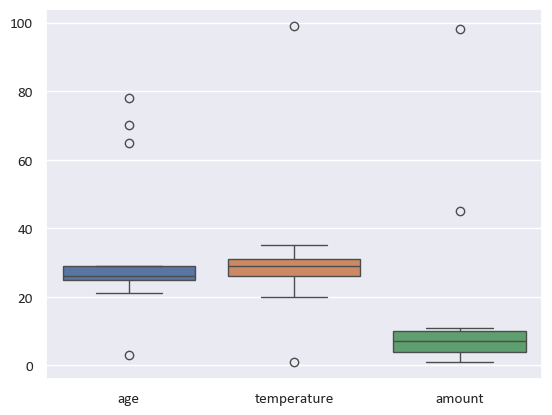

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style= 'darkgrid', palette= 'deep', font= 'calibri', font_scale= 1)

sns.boxplot(df)

plt.show()

<Axes: >

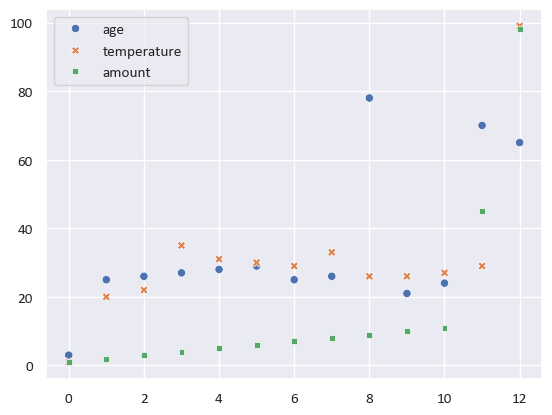

In [66]:
sns.scatterplot(df)

<Axes: xlabel='None', ylabel='age'>

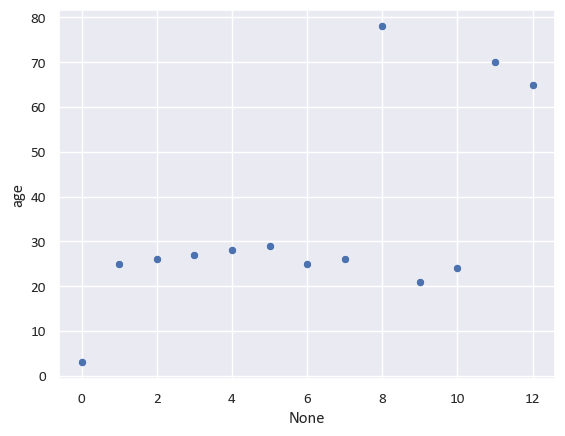

In [67]:
sns.scatterplot(df, y= df.age, x = df.index)

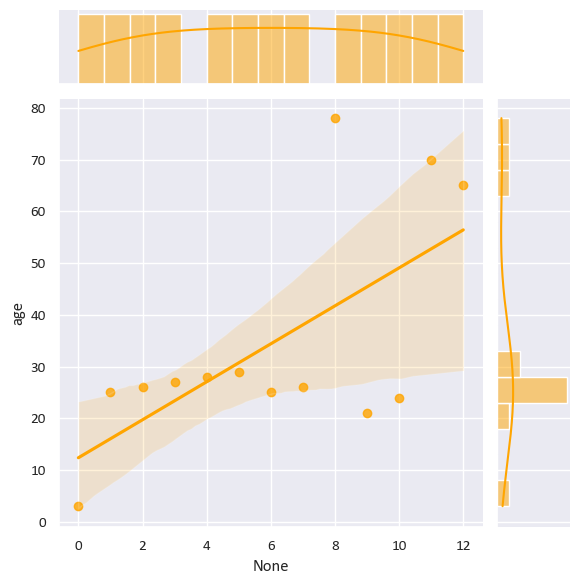

In [68]:
sns.jointplot(df, x=df.index, y = df.age, kind = 'reg', color = 'orange', 
              marginal_kws= dict(bins = 15, fill = True))

### Handle Outliers:
- Z - score method

$$z = (x – μ) / σ$$




<Axes: >

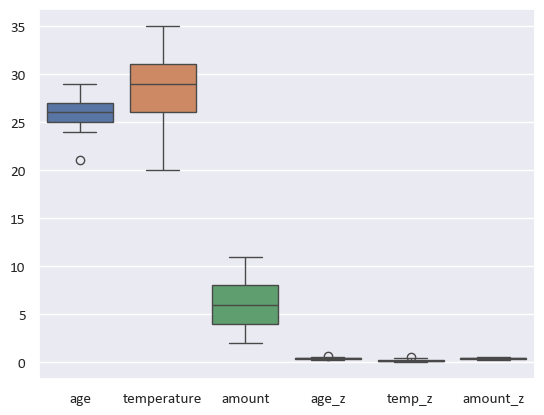

In [69]:
import numpy as np
from scipy import stats


# we need z-score for each series

df['age_z'] = np.abs(stats.zscore(df['age']))
df['temp_z'] = np.abs(stats.zscore(df['temperature']))
df['amount_z'] = np.abs(stats.zscore(df['amount']))

# data is more than 3 standard deviations away
# z  score > 1.3 means outlier

# Exerciseeeeeeeeeeeeee
outliers = df[(df['age_z'] > 1.3) | (df['temp_z'] > 1.3) | (df['amount_z'] > 1.3)] # boolean filter: if any of these is agez, tempz, amountz > 1.3, get those in the df
outliers

df_clean = df.drop(index = outliers.index)

sns.boxplot(df_clean)

In [70]:
df[(df['age_z'] > 1.3) | (df['temp_z'] > 1.3) | (df['amount_z'] > 1.3)]

,age,temperature,amount,age_z,temp_z,amount_z
0,3,1,1,1.483156,1.436145,0.580314
8,78,26,9,2.061151,0.254507,0.272392
11,70,29,45,1.683091,0.112710,1.113255
12,65,99,98,1.446804,3.195878,3.153235


### Other way

- IQR method using bounds
- 

In [71]:
# df.drop(['age_z','amount_z','temp_z'],axis=1, inplace = True)

In [80]:
col = df.age
col

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q1 + 1.5 * IQR


age_clean = col[(col > lower) & (col < upper)]
age_clean


1     25
2     26
3     27
4     28
5     29
6     25
7     26
9     21
10    24
Name: age, dtype: int64

In [ ]:
# From Multiple columns at the same time


num_cols = df.select_dtypes(include = 'number')
num_cols


for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q1 + 1.5 * IQR

    df_clean2 = df[(df[col] >= lower) & (df[col] <= upper) ] 

df_clean2

,age,temperature,amount,age_z,temp_z,amount_z
0,3,1,1,1.483156,1.436145,0.580314
1,25,20,2,0.443493,0.538100,0.541823
2,26,22,3,0.396235,0.443569,0.503333
3,27,35,4,0.348978,0.170883,0.464843
4,28,31,5,0.301720,0.018179,0.426353
5,29,30,6,0.254463,0.065445,0.387863
6,25,29,7,0.443493,0.112710,0.349372
7,26,33,8,0.396235,0.076352,0.310882
8,78,26,9,2.061151,0.254507,0.272392
9,21,26,10,0.632522,0.254507,0.233902
